# E-Commerce Sales & Customer Analytics
Synthetic portfolio project using Python, Pandas and Matplotlib.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
df = pd.read_csv('../data/ecommerce_sales.csv', parse_dates=['order_date'])
df.head()

,order_id,order_date,customer_id,customer_name,customer_segment,state,city,category,product,quantity,unit_price,discount_pct,sales,payment_method,channel,order_status
0,1,2025-02-26,CUST02423,Maya White,Corporate,Connecticut,Hartford,Electronics,Bluetooth Speaker,1,287.13,0.05,272.77,Apple Pay,Website,Completed
1,2,2026-05-09,CUST03477,Taylor Moore,Home Office,Michigan,Grand Rapids,Books,Cookbook,2,38.84,0.00,77.68,PayPal,Marketplace,Completed
2,3,2026-02-22,CUST03234,Naveen Brown,Home Office,Pennsylvania,Allentown,Clothing,Hoodie,3,95.78,0.10,258.61,Credit Card,Mobile App,Completed
3,4,2025-10-08,CUST01920,Daniel Moore,Home Office,Tennessee,Nashville,Home & Kitchen,Air Fryer,1,290.69,0.00,290.69,Credit Card,Website,Completed
4,5,2025-10-04,CUST02134,Cameron Miller,Home Office,Illinois,Chicago,Home & Kitchen,Blender,2,162.90,0.20,260.64,Debit Card,Mobile App,Completed


In [2]:
kpis = {
    'Orders': df.order_id.nunique(),
    'Customers': df.customer_id.nunique(),
    'Revenue': round(df.sales.sum(), 2),
    'Units Sold': int(df.quantity.sum()),
    'AOV': round(df.sales.sum()/df.order_id.nunique(), 2),
    'Return Rate %': round(df.order_status.eq('Returned').mean()*100, 2)
}
kpis

{'Orders': 12000,
 'Customers': 2489,
 'Revenue': np.float64(2581199.81),
 'Units Sold': 18510,
 'AOV': np.float64(215.1),
 'Return Rate %': np.float64(6.81)}

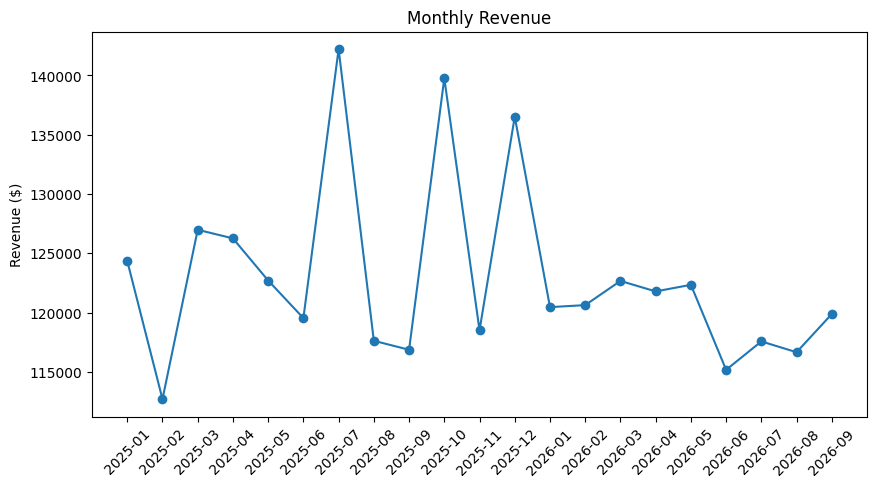

In [3]:
monthly = df.assign(month=df.order_date.dt.to_period('M').astype(str)).groupby('month', as_index=False)['sales'].sum()
plt.figure(figsize=(10,5)); plt.plot(monthly.month, monthly.sales, marker='o'); plt.xticks(rotation=45); plt.title('Monthly Revenue'); plt.ylabel('Revenue ($)'); plt.show()

In [4]:
category = df.groupby('category', as_index=False)['sales'].sum().sort_values('sales', ascending=False)
category

,category,sales
3,Electronics,1084058.31
4,Home & Kitchen,560021.51
2,Clothing,350203.86
5,Sports,288122.59
0,Beauty,229416.67
1,Books,69376.87


In [5]:
state = df.groupby('state', as_index=False)['sales'].sum().sort_values('sales', ascending=False)
state.head(10)

,state,sales
12,Tennessee,182938.68
1,Arizona,181597.74
5,Georgia,178776.17
14,Virginia,176322.46
13,Texas,175933.09
2,California,175441.01
6,Illinois,175009.88
10,Ohio,171660.56
8,New York,169328.08
3,Connecticut,168243.24
